<a href="https://colab.research.google.com/github/AhmedAlmufarriji/time-series-forecasting-capstone/blob/main/time_series_forecasting_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workforce Demand Forecasting Under a Structural Break

## A Backtested, Uncertainty-Aware Forecasting Report

**Team Leader:** Ahmed Almufarriji  
**Team Member:** Abdulaziz Bakhadlaq  

**Programme:** SDAIA Academy — Time Series Forecasting for AI Systems  
**Cohort:** September 2026  
**Dataset:** `data/workforce_demand.csv` (official course synthetic dataset)

### Project Question

Can a forecasting workflow remain accurate, leakage-safe, and uncertainty-aware when the underlying workforce-demand process experiences a structural break?

This project deliberately uses the workforce-demand series instead of the course's main retail example. The structural break makes the validation design itself part of the modeling problem and creates a meaningful reason to compare **expanding vs. rolling windows**, which is a direct requirement of the grading rubric.

The dataset is synthetic and deterministic. No result in this notebook represents a real employer, contact center, or government workforce series.

## 1. Setup and official course utilities

The notebook uses the course's own `common/metrics.py` and `common/backtest.py` modules so that the metric definitions and walk-forward logic match the course exactly. The same cell works in a fresh Colab runtime or in a local clone. No API key is needed.


In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install(
    "pandas", "numpy", "matplotlib", "statsmodels", "scikit-learn", "lightgbm",
    "prophet==1.4.0", "cmdstanpy==1.3.0", "sktime"
)

import pathlib, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"
RNG_SEED = 20260912
np.random.seed(RNG_SEED)

def fetch(rel_path: str) -> str:
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, wape, mase, pinball_loss, coverage, interval_width

sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

print("Environment ready.")


Environment ready.


## 2. Load and validate the workforce-demand series

The series is daily from 2024-01-01 through 2025-12-31. The generator introduces a sustained level shift beginning on **2025-04-01**. This makes the dataset useful for testing whether older observations should remain in the training window after the regime changes.


In [2]:
df = pd.read_csv(fetch("data/workforce_demand.csv"), parse_dates=["date"])
series = df.set_index("date")["required_headcount"].asfreq("D")
BREAK_DATE = pd.Timestamp("2025-04-01")

quality = pd.Series({
    "rows": len(series),
    "start": series.index.min(),
    "end": series.index.max(),
    "missing": int(series.isna().sum()),
    "zero_values": int((series == 0).sum()),
    "mean": float(series.mean()),
    "std": float(series.std()),
})
quality


,0
rows,731
start,2024-01-01 00:00:00
end,2025-12-31 00:00:00
missing,0
zero_values,0
mean,70.344733
std,25.366117


In [3]:
pre_break = series.loc[series.index < BREAK_DATE]
post_break = series.loc[series.index >= BREAK_DATE]

break_summary = pd.DataFrame({
    "period": ["before 2025-04-01", "on/after 2025-04-01"],
    "observations": [len(pre_break), len(post_break)],
    "mean_headcount": [pre_break.mean(), post_break.mean()],
    "median_headcount": [pre_break.median(), post_break.median()],
}).set_index("period")
break_summary


,observations,mean_headcount,median_headcount
period,,,
before 2025-04-01,456,60.561404,68.0
on/after 2025-04-01,275,86.567273,99.0


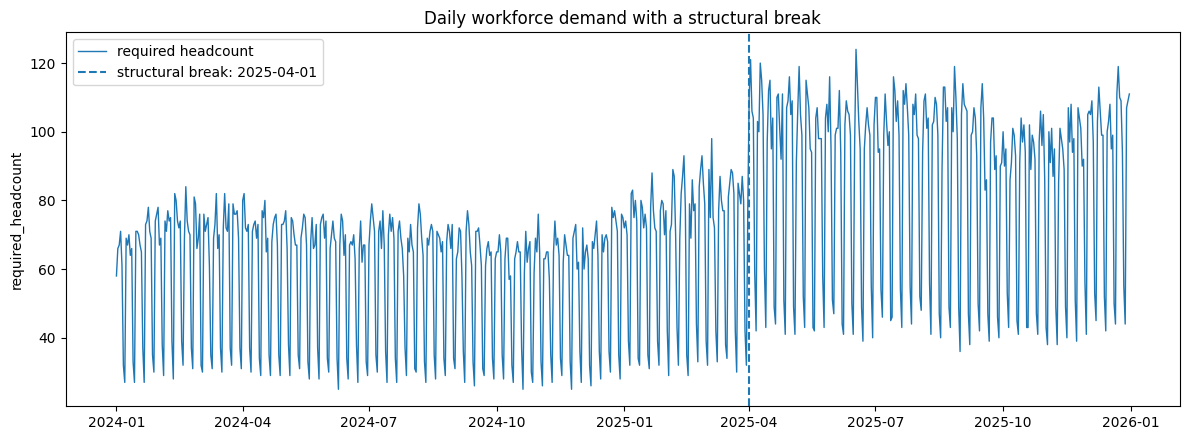

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(series.index, series.values, linewidth=1.0, label="required headcount")
ax.axvline(BREAK_DATE, linestyle="--", linewidth=1.5, label="structural break: 2025-04-01")
ax.set_title("Daily workforce demand with a structural break")
ax.set_ylabel("required_headcount")
ax.legend()
plt.tight_layout()
plt.show()


**Initial data read.** The series has no missing dates and no zero values, so MAE/RMSE are easy to interpret in headcount units and both WAPE and MASE are valid scale-aware metrics. The sharp level change is operationally important: a validation scheme that keeps all old history forever may react differently from one that deliberately ages stale history out.


## 3. Time-series structure and diagnostics
### 3.1 Robust STL decomposition

The dominant short seasonal period is weekly (`period=7`). `robust=True` reduces the influence of unusual days when estimating the slow-moving component.


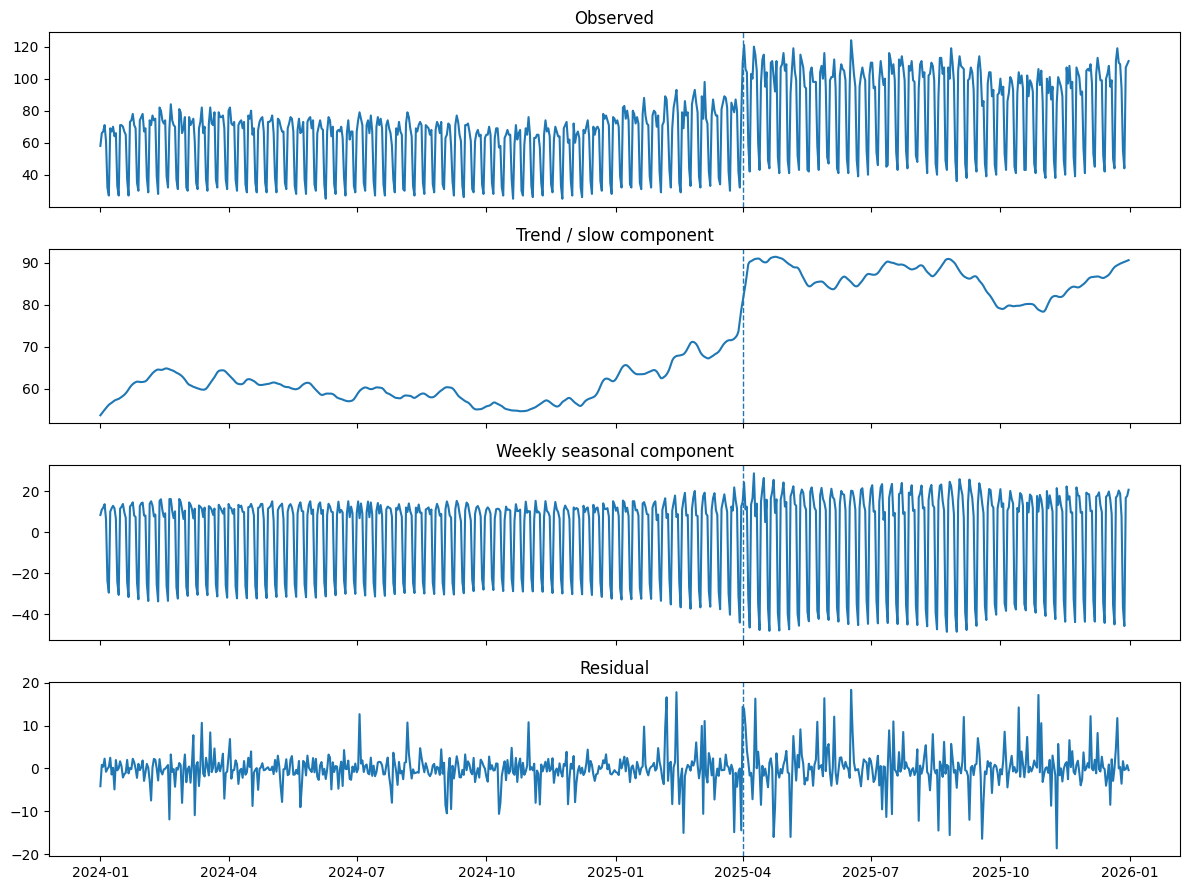

,0
seasonal_min,-48.656678
seasonal_max,28.825068
residual_std,4.156536


In [5]:
from statsmodels.tsa.seasonal import STL

stl = STL(series, period=7, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(series.index, series.values)
axes[0].set_title("Observed")
axes[1].plot(stl.trend.index, stl.trend.values)
axes[1].set_title("Trend / slow component")
axes[2].plot(stl.seasonal.index, stl.seasonal.values)
axes[2].set_title("Weekly seasonal component")
axes[3].plot(stl.resid.index, stl.resid.values)
axes[3].set_title("Residual")
for ax in axes:
    ax.axvline(BREAK_DATE, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

pd.Series({
    "seasonal_min": stl.seasonal.min(),
    "seasonal_max": stl.seasonal.max(),
    "residual_std": stl.resid.std(),
})


### 3.2 ACF/PACF

ACF and PACF are computed rather than inferred by eye. The raw ACF is expected to show strong persistence at lag 7 and its multiples because the staffing requirement has a pronounced weekly rhythm. The differenced plots are used to check what structure remains after removing the changing level.


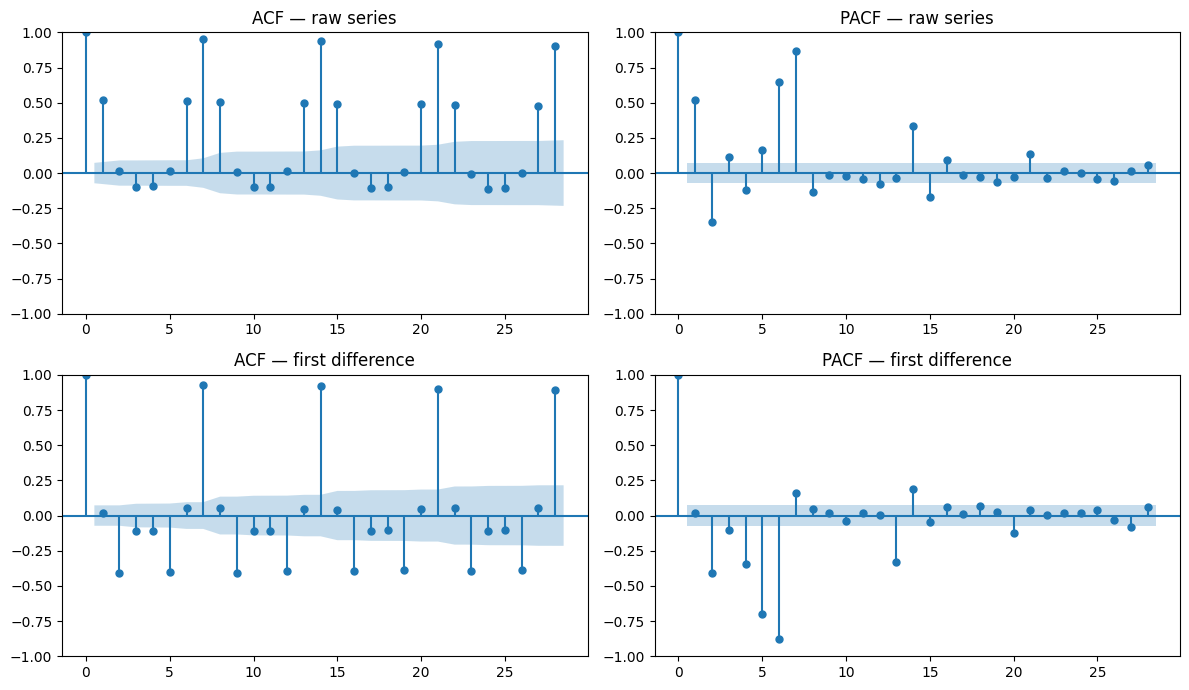

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

first_diff = series.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(series, lags=28, ax=axes[0,0])
axes[0,0].set_title("ACF — raw series")
plot_pacf(series, lags=28, ax=axes[0,1], method="ywm")
axes[0,1].set_title("PACF — raw series")
plot_acf(first_diff, lags=28, ax=axes[1,0])
axes[1,0].set_title("ACF — first difference")
plot_pacf(first_diff, lags=28, ax=axes[1,1], method="ywm")
axes[1,1].set_title("PACF — first difference")
plt.tight_layout()
plt.show()


### 3.3 ADF stationarity test and motivated differencing

The ADF null hypothesis is that the series contains a unit root. The decision is not based on the p-value alone: it is read together with the visible level shift and the autocorrelation pattern. Differencing is applied only after that diagnosis.


In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_result(x, label):
    r = adfuller(pd.Series(x).dropna(), autolag="AIC")
    return {
        "series": label,
        "ADF statistic": r[0],
        "p-value": r[1],
        "used lags": r[2],
        "observations": r[3],
    }

adf_table = pd.DataFrame([
    adf_result(series, "raw"),
    adf_result(series.diff(), "first difference"),
    adf_result(series.diff(7), "seasonal difference (lag 7)"),
]).set_index("series")
adf_table


/tmp/ipykernel_1198/2386326129.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r = adfuller(pd.Series(x).dropna(), autolag="AIC")
/tmp/ipykernel_1198/2386326129.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r = adfuller(pd.Series(x).dropna(), autolag="AIC")
/tmp/ipykernel_1198/2386326129.py:4: FutureWarning: adfuller currently returns a plain tuple whose length 

,ADF statistic,p-value,used lags,observations
series,,,,
raw,-0.563394,8.790408e-01,20,710
first difference,-8.210925,6.822099e-13,19,710
seasonal difference (lag 7),-6.327194,2.966408e-08,20,703


**Stationarity interpretation.** On this deterministic course dataset, the raw series is clearly non-stationary because of the trend/level change and the ADF result does not reject the unit-root null. A first difference makes the ADF result strongly stationary, while lag-7 differencing directly attacks the weekly seasonal persistence. That evidence motivates the integrated and seasonal-differencing terms used in the SARIMAX candidates below; differencing is not inserted as an arbitrary default.


## 4. Classical forecasting models
### 4.1 SARIMAX order selection by AIC/BIC

A 60-day final holdout is kept completely out of model selection. Candidate SARIMAX models are compared with the same differencing orders (`d=1`, `D=1`, `s=7`) so that AIC/BIC comparisons are on a consistent footing. The search chooses the autoregressive/moving-average structure; it does not guess one configuration and stop.


In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

HORIZON = 60
train = series.iloc[:-HORIZON]
test = series.iloc[-HORIZON:]

rows = []
fitted_candidates = {}
for p, q, P, Q in itertools.product([0, 1], [0, 1, 2], [0, 1], [0, 1]):
    order = (p, 1, q)
    seasonal_order = (P, 1, Q, 7)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fit = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False, maxiter=100)
        rows.append({"order": order, "seasonal_order": seasonal_order, "AIC": fit.aic, "BIC": fit.bic})
        fitted_candidates[(order, seasonal_order)] = fit
    except Exception:
        pass

ic_table = pd.DataFrame(rows).sort_values(["AIC", "BIC"]).reset_index(drop=True)
ic_table.head(10)


,order,seasonal_order,AIC,BIC
0,"(1, 1, 2)","(0, 1, 1, 7)",4064.590662,4086.998548
1,"(0, 1, 2)","(0, 1, 1, 7)",4064.845377,4082.771686
2,"(1, 1, 2)","(1, 1, 1, 7)",4066.577014,4093.466477
3,"(0, 1, 2)","(1, 1, 1, 7)",4067.694056,4090.101942
4,"(1, 1, 1)","(0, 1, 1, 7)",4071.256336,4089.188766
5,"(1, 1, 1)","(1, 1, 1, 7)",4074.449535,4096.865072
6,"(0, 1, 1)","(0, 1, 1, 7)",4075.938863,4089.388186
7,"(0, 1, 1)","(1, 1, 1, 7)",4077.931880,4095.864310
8,"(1, 1, 2)","(1, 1, 0, 7)",4198.145146,4220.568322
9,"(1, 1, 1)","(1, 1, 0, 7)",4198.228657,4216.167198


In [9]:
best_order = tuple(ic_table.iloc[0]["order"])
best_seasonal_order = tuple(ic_table.iloc[0]["seasonal_order"])
sarimax_fit = fitted_candidates[(best_order, best_seasonal_order)]
sarimax_pred = sarimax_fit.forecast(HORIZON)

pd.Series({
    "selected_order": str(best_order),
    "selected_seasonal_order": str(best_seasonal_order),
    "AIC": sarimax_fit.aic,
    "BIC": sarimax_fit.bic,
    "holdout_MAE": mae(test.values, sarimax_pred.values),
    "holdout_RMSE": rmse(test.values, sarimax_pred.values),
    "holdout_WAPE_pct": wape(test.values, sarimax_pred.values),
    "holdout_MASE": mase(test.values, sarimax_pred.values, train.values, seasonal_period=7),
})


,0
selected_order,"(1, 1, 2)"
selected_seasonal_order,"(0, 1, 1, 7)"
AIC,4064.590662
BIC,4086.998548
holdout_MAE,7.574991
holdout_RMSE,9.001682
holdout_WAPE_pct,8.837244
holdout_MASE,1.583688


### 4.2 Exponential-smoothing family

SES, Holt, and Holt-Winters are all actually fitted. This separates the value of level-only, trend, and trend+weekly-seasonality assumptions. Cross-family decisions use out-of-sample error rather than comparing ETS AIC directly with SARIMAX AIC.


In [10]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ses_fit = SimpleExpSmoothing(train, initialization_method="estimated").fit()
    holt_fit = Holt(train, initialization_method="estimated").fit()
    hw_add_fit = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=7,
        initialization_method="estimated"
    ).fit()
    hw_mul_fit = ExponentialSmoothing(
        train, trend="add", seasonal="mul", seasonal_periods=7,
        initialization_method="estimated"
    ).fit()

classical_forecasts = {
    "SARIMAX": np.asarray(sarimax_pred),
    "SES": np.asarray(ses_fit.forecast(HORIZON)),
    "Holt": np.asarray(holt_fit.forecast(HORIZON)),
    "Holt-Winters additive": np.asarray(hw_add_fit.forecast(HORIZON)),
    "Holt-Winters multiplicative": np.asarray(hw_mul_fit.forecast(HORIZON)),
    "seasonal-naive": seasonal_naive_forecast(train.values, HORIZON, period=7),
}

classical_scores = []
for name, pred in classical_forecasts.items():
    classical_scores.append({
        "model": name,
        "MAE": mae(test.values, pred),
        "RMSE": rmse(test.values, pred),
        "WAPE (%)": wape(test.values, pred),
        "MASE": mase(test.values, pred, train.values, seasonal_period=7),
    })
pd.DataFrame(classical_scores).set_index("model").sort_values("WAPE (%)").round(3)


,MAE,RMSE,WAPE (%),MASE
model,,,,
Holt-Winters additive,5.168,6.416,6.029,1.080
Holt-Winters multiplicative,7.117,8.749,8.303,1.488
SARIMAX,7.575,9.002,8.837,1.584
seasonal-naive,7.683,8.889,8.964,1.606
SES,23.780,26.014,27.742,4.972
Holt,26.572,27.935,31.000,5.555


### 4.3 Ljung-Box residual diagnostic

The Ljung-Box null hypothesis is that the residuals are not autocorrelated up to the tested lag. Large p-values are evidence that the selected SARIMAX has removed the recurring temporal structure rather than simply fitting the level.


In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(sarimax_fit.resid.dropna(), lags=[7, 14, 21], return_df=True)
ljung_box


,lb_stat,lb_pvalue
7,10.923960,0.141970
14,19.799846,0.136579
21,25.777746,0.215051


## 5. LightGBM with temporal feature engineering

A tree model has no built-in recurrence. The feature table therefore creates lag values, rolling statistics, and calendar features. Every lag/rolling statistic is based on past observations only. Rolling windows explicitly begin from `shift(1)` so the target on day *t* cannot leak into its own predictors.


In [12]:
from lightgbm import LGBMRegressor

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_std_7", "roll_mean_28",
    "dayofweek", "month", "is_weekend", "doy_sin", "doy_cos",
]

def make_features(y: pd.Series) -> pd.DataFrame:
    feat = pd.DataFrame({"y": y})
    feat["lag_1"] = y.shift(1)
    feat["lag_7"] = y.shift(7)
    feat["lag_14"] = y.shift(14)
    feat["lag_28"] = y.shift(28)
    shifted = y.shift(1)
    feat["roll_mean_7"] = shifted.rolling(7).mean()
    feat["roll_std_7"] = shifted.rolling(7).std()
    feat["roll_mean_28"] = shifted.rolling(28).mean()
    feat["dayofweek"] = feat.index.dayofweek
    feat["month"] = feat.index.month
    feat["is_weekend"] = feat.index.dayofweek.isin([4, 5]).astype(int)  # Fri/Sat context
    doy = feat.index.dayofyear
    feat["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    feat["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return feat

train_features = make_features(train).dropna()
train_features[["y"] + FEATURE_COLS].head()


,y,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_28,dayofweek,month,is_weekend,doy_sin,doy_cos
date,,,,,,,,,,,,,
2024-01-29,74.0,30.0,73.0,71.0,58.0,61.428571,20.007142,57.714286,0,1,0,0.478434,0.878124
2024-01-30,76.0,74.0,74.0,71.0,66.0,61.571429,20.106857,58.285714,1,1,0,0.493468,0.869764
2024-01-31,78.0,76.0,78.0,70.0,67.0,61.857143,20.325916,58.642857,2,1,0,0.508356,0.861147
2024-02-01,67.0,78.0,71.0,67.0,71.0,61.857143,20.325916,59.035714,3,2,0,0.523094,0.852275
2024-02-02,69.0,67.0,69.0,65.0,61.0,61.285714,20.080789,58.892857,4,2,1,0.537677,0.843151


In [13]:
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15,
    random_state=RNG_SEED,
    verbosity=-1,
)
lgb_model.fit(train_features[FEATURE_COLS], train_features["y"])
print("LightGBM fitted on", len(train_features), "training rows and", len(FEATURE_COLS), "features")


LightGBM fitted on 643 training rows and 12 features


### 5.1 Leakage-safe recursive multi-step forecast

For day 2 of a multi-day forecast, `lag_1` is not allowed to use day 1's true holdout value. It must use the model's own day-1 prediction. The loop below appends predictions to a working history and never appends a held-out actual. Assertions make that boundary visible.


In [14]:
def recursive_forecast(model, history: pd.Series, future_dates: pd.DatetimeIndex) -> np.ndarray:
    working = history.copy()
    preds = []
    for date in future_dates:
        assert working.index[-1] == date - pd.Timedelta(days=1)
        assert date not in working.index
        extended = pd.concat([working, pd.Series([np.nan], index=[date])])
        row = make_features(extended).loc[[date], FEATURE_COLS]
        pred = float(model.predict(row)[0])
        preds.append(pred)
        working.loc[date] = pred
    return np.asarray(preds)

lgb_pred = recursive_forecast(lgb_model, train, test.index)
naive_pred = seasonal_naive_forecast(train.values, HORIZON, period=7)

ml_scores = pd.DataFrame({
    "LightGBM recursive": {
        "MAE": mae(test.values, lgb_pred),
        "RMSE": rmse(test.values, lgb_pred),
        "WAPE (%)": wape(test.values, lgb_pred),
        "MASE": mase(test.values, lgb_pred, train.values, seasonal_period=7),
    },
    "seasonal-naive": {
        "MAE": mae(test.values, naive_pred),
        "RMSE": rmse(test.values, naive_pred),
        "WAPE (%)": wape(test.values, naive_pred),
        "MASE": mase(test.values, naive_pred, train.values, seasonal_period=7),
    },
}).T
ml_scores.round(3)


,MAE,RMSE,WAPE (%),MASE
LightGBM recursive,5.515,6.595,6.434,1.153
seasonal-naive,7.683,8.889,8.964,1.606


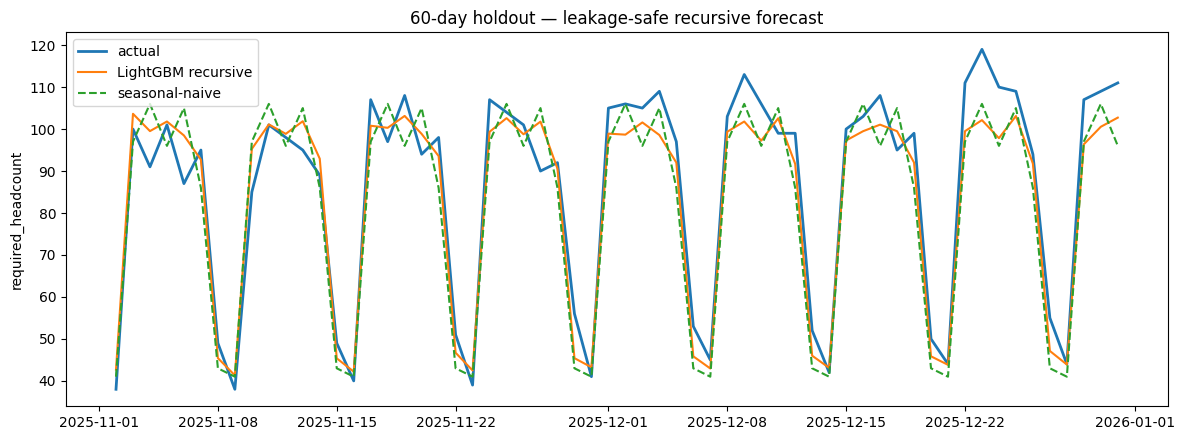

In [15]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test.index, test.values, label="actual", linewidth=2)
ax.plot(test.index, lgb_pred, label="LightGBM recursive")
ax.plot(test.index, naive_pred, label="seasonal-naive", linestyle="--")
ax.set_title("60-day holdout — leakage-safe recursive forecast")
ax.set_ylabel("required_headcount")
ax.legend()
plt.tight_layout()
plt.show()


**Leakage statement.** The risk is not merely conceptual. Lag and rolling features can silently read future actuals when a full dataframe is engineered before a split. Here, feature engineering is rebuilt from each fold's own training history. During a multi-step forecast, only predictions are fed forward. No held-out actual crosses a fold boundary or enters a future lag.


## 6. Walk-forward backtesting — expanding **and** rolling windows

This dataset makes the window choice substantive rather than decorative. An expanding window preserves all pre-break history; a rolling one eventually removes stale pre-break observations. Both designs use the shared course split functions and `run_backtest`, and every model is fitted fresh inside the callback for every fold.

Primary comparison: **5 folds × 14 days**, with at least one year of training history.


In [16]:
N_FOLDS = 5
BT_HORIZON = 14
MIN_TRAIN = 365
ROLL_TRAIN = 365

expanding_splits = expanding_window_splits(
    n=len(series), n_folds=N_FOLDS, horizon=BT_HORIZON, min_train_size=MIN_TRAIN
)
rolling_splits = rolling_window_splits(
    n=len(series), n_folds=N_FOLDS, horizon=BT_HORIZON, train_size=ROLL_TRAIN
)

def split_table(splits, label):
    rows = []
    for i, (tr, te) in enumerate(splits):
        rows.append({
            "window": label,
            "fold": i,
            "train_start": series.index[tr.start or 0],
            "train_end": series.index[tr.stop - 1],
            "test_start": series.index[te.start],
            "test_end": series.index[te.stop - 1],
        })
    return pd.DataFrame(rows)

pd.concat([split_table(expanding_splits, "expanding"), split_table(rolling_splits, "rolling")], ignore_index=True)


,window,fold,train_start,train_end,test_start,test_end
0,expanding,0,2024-01-01,2025-10-22,2025-10-23,2025-11-05
1,expanding,1,2024-01-01,2025-11-05,2025-11-06,2025-11-19
2,expanding,2,2024-01-01,2025-11-19,2025-11-20,2025-12-03
3,expanding,3,2024-01-01,2025-12-03,2025-12-04,2025-12-17
4,expanding,4,2024-01-01,2025-12-17,2025-12-18,2025-12-31
5,rolling,0,2024-10-23,2025-10-22,2025-10-23,2025-11-05
6,rolling,1,2024-11-06,2025-11-05,2025-11-06,2025-11-19
7,rolling,2,2024-11-20,2025-11-19,2025-11-20,2025-12-03
8,rolling,3,2024-12-04,2025-12-03,2025-12-04,2025-12-17
9,rolling,4,2024-12-18,2025-12-17,2025-12-18,2025-12-31


In [17]:
def naive_fit_predict(y_train, horizon):
    return seasonal_naive_forecast(y_train, horizon, period=7)

def hw_fit_predict(y_train, horizon):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ExponentialSmoothing(
            y_train, trend="add", seasonal="add", seasonal_periods=7,
            initialization_method="estimated"
        ).fit()
    return np.asarray(model.forecast(horizon))

def lgb_fit_predict_factory(full_series: pd.Series, splits):
    # run_backtest calls the function in the same order as `splits`.
    # The small counter lets the callback recover the correct real dates,
    # which is essential for calendar features in a rolling window.
    state = {"fold": 0}
    def _fit_predict(y_train, horizon):
        fold = state["fold"]
        state["fold"] += 1
        train_slice, _ = splits[fold]
        idx = full_series.index[train_slice]
        assert len(idx) == len(y_train)
        history = pd.Series(y_train, index=idx)
        feats = make_features(history).dropna()
        model = LGBMRegressor(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=15,
            min_child_samples=10,
            random_state=RNG_SEED,
            verbosity=-1,
        )
        model.fit(feats[FEATURE_COLS], feats["y"])
        future_dates = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
        return recursive_forecast(model, history, future_dates)
    return _fit_predict


In [18]:
backtests = {}
for window_name, splits in [("expanding", expanding_splits), ("rolling", rolling_splits)]:
    backtests[(window_name, "seasonal-naive")] = run_backtest(series.values, splits, naive_fit_predict)
    backtests[(window_name, "Holt-Winters")] = run_backtest(series.values, splits, hw_fit_predict)
    backtests[(window_name, "LightGBM recursive")] = run_backtest(
        series.values, splits, lgb_fit_predict_factory(series, splits)
    )

rows = []
for (window, model), results in backtests.items():
    for r in results:
        rows.append({
            "window": window,
            "model": model,
            "fold": r["fold"],
            "MAE": mae(r["y_true"], r["y_pred"]),
            "RMSE": rmse(r["y_true"], r["y_pred"]),
            "WAPE (%)": wape(r["y_true"], r["y_pred"]),
            "MASE": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
        })
backtest_df = pd.DataFrame(rows)
backtest_df.round(3)


,window,model,fold,MAE,RMSE,WAPE (%),MASE
0,expanding,seasonal-naive,0,4.286,5.868,5.263,0.898
1,expanding,seasonal-naive,1,7.286,8.693,8.963,1.520
2,expanding,seasonal-naive,2,4.071,5.092,4.794,0.838
3,expanding,seasonal-naive,3,5.214,6.840,5.940,1.078
4,expanding,seasonal-naive,4,5.214,6.745,5.807,1.077
5,expanding,Holt-Winters,0,3.975,4.885,4.882,0.833
6,expanding,Holt-Winters,1,4.614,5.865,5.676,0.963
7,expanding,Holt-Winters,2,4.146,4.773,4.882,0.853
8,expanding,Holt-Winters,3,2.585,4.161,2.945,0.534
9,expanding,Holt-Winters,4,4.351,5.558,4.846,0.898


In [19]:
backtest_summary = (
    backtest_df.groupby(["window", "model"])[["MAE", "RMSE", "WAPE (%)", "MASE"]]
    .agg(["mean", "std"])
    .round(3)
)
backtest_summary


MAE          RMSE        WAPE (%)         \
                               mean    std   mean    std     mean    std   
window    model                                                            
expanding Holt-Winters        3.934  0.791  5.048  0.674    4.646  1.013   
          LightGBM recursive  4.194  0.612  5.332  0.561    4.944  0.779   
          seasonal-naive      5.214  1.271  6.648  1.347    6.153  1.636   
rolling   Holt-Winters        3.894  0.782  4.986  0.698    4.601  1.020   
          LightGBM recursive  4.588  0.526  5.883  0.545    5.403  0.649   
          seasonal-naive      5.214  1.271  6.648  1.347    6.153  1.636   

                               MASE         
                               mean    std  
window    model                             
expanding Holt-Winters        0.816  0.165  
          LightGBM recursive  0.870  0.125  
          seasonal-naive      1.082  0.267  
rolling   Holt-Winters        0.678  0.141  
          LightGBM recursive  0.797  0.088  
          seasonal-naive      0.908  0.230

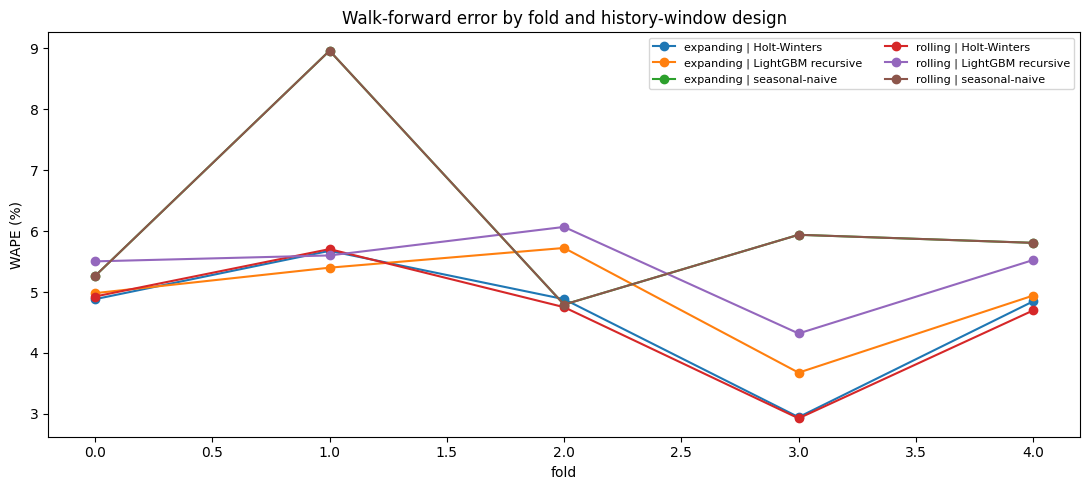

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
for (window, model), grp in backtest_df.groupby(["window", "model"]):
    ax.plot(grp["fold"], grp["WAPE (%)"], marker="o", label=f"{window} | {model}")
ax.set_xlabel("fold")
ax.set_ylabel("WAPE (%)")
ax.set_title("Walk-forward error by fold and history-window design")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()


### 6.1 Structural-break stress test — a creative validation extension

The primary backtest above measures recent forecasting behavior. To test the reason this dataset was selected, this second walk-forward experiment intentionally ends shortly after the known break and places one test fold exactly across **2025-04-01**. The goal is not to tune on the break date; it is to show how validation exposes a regime shift and how quickly expanding versus rolling histories recover afterward.


In [21]:
stress_series = series.loc[:"2025-05-20"]
STRESS_FOLDS = 8
STRESS_HORIZON = 10

stress_exp = expanding_window_splits(
    n=len(stress_series), n_folds=STRESS_FOLDS, horizon=STRESS_HORIZON, min_train_size=365
)
stress_roll = rolling_window_splits(
    n=len(stress_series), n_folds=STRESS_FOLDS, horizon=STRESS_HORIZON, train_size=365
)

stress_results = []
for window_name, splits in [("expanding", stress_exp), ("rolling", stress_roll)]:
    model_results = {
        "seasonal-naive": run_backtest(stress_series.values, splits, naive_fit_predict),
        "Holt-Winters": run_backtest(stress_series.values, splits, hw_fit_predict),
        "LightGBM recursive": run_backtest(
            stress_series.values, splits, lgb_fit_predict_factory(stress_series, splits)
        ),
    }
    for model_name, results in model_results.items():
        for r, (_, te) in zip(results, splits):
            stress_results.append({
                "window": window_name,
                "model": model_name,
                "fold": r["fold"],
                "test_start": stress_series.index[te.start],
                "test_end": stress_series.index[te.stop - 1],
                "WAPE (%)": wape(r["y_true"], r["y_pred"]),
                "MAE": mae(r["y_true"], r["y_pred"]),
            })
stress_df = pd.DataFrame(stress_results)
stress_df.round(3)


,window,model,fold,test_start,test_end,WAPE (%),MAE
0,expanding,seasonal-naive,0,2025-03-02,2025-03-11,7.941,5.400
1,expanding,seasonal-naive,1,2025-03-12,2025-03-21,9.302,6.800
2,expanding,seasonal-naive,2,2025-03-22,2025-03-31,5.975,3.800
3,expanding,seasonal-naive,3,2025-04-01,2025-04-10,25.816,25.300
4,expanding,seasonal-naive,4,2025-04-11,2025-04-20,7.039,5.800
5,expanding,seasonal-naive,5,2025-04-21,2025-04-30,6.006,5.700
6,expanding,seasonal-naive,6,2025-05-01,2025-05-10,7.420,6.500
7,expanding,seasonal-naive,7,2025-05-11,2025-05-20,9.524,8.200
8,expanding,Holt-Winters,0,2025-03-02,2025-03-11,10.702,7.277
9,expanding,Holt-Winters,1,2025-03-12,2025-03-21,4.819,3.523


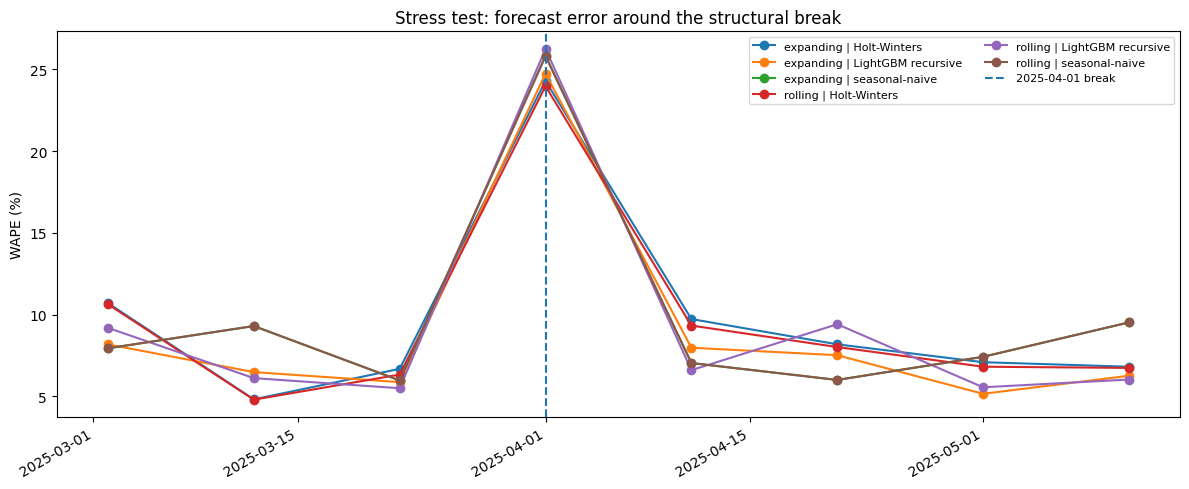

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
for (window, model), grp in stress_df.groupby(["window", "model"]):
    ax.plot(grp["test_start"], grp["WAPE (%)"], marker="o", label=f"{window} | {model}")
ax.axvline(BREAK_DATE, linestyle="--", linewidth=1.5, label="2025-04-01 break")
ax.set_ylabel("WAPE (%)")
ax.set_title("Stress test: forecast error around the structural break")
ax.legend(fontsize=8, ncol=2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Backtesting interpretation.** The fold that begins on the structural-break date should show a sharp error spike because none of the models can know about an unseen regime shift in advance. That is evidence of honest validation, not model failure. After post-break observations arrive, error should recover. The expanding/rolling comparison then becomes an operational choice: expanding retains more data; rolling forgets stale regimes faster. The final deployment decision below uses both error level and stability rather than one holdout score.


## 7. Evaluation metrics and reporting

The notebook reports **MAE** and **RMSE** in headcount units, plus two scale-aware metrics from the shared course module:

- **WAPE** gives total absolute error as a percentage of total actual demand. This workforce series has no zero/near-zero problem, so it is stable and intuitive.
- **MASE** scales error against a weekly seasonal-naive benchmark (`seasonal_period=7`). A value below 1 means the model beats that in-sample seasonal-naive yardstick.

MAPE is not needed here; WAPE and MASE provide more useful cross-window comparisons and tie directly to the baseline used in the backtest.


In [23]:
latest_metric_table = (
    backtest_df.groupby(["window", "model"])[["MAE", "RMSE", "WAPE (%)", "MASE"]]
    .mean()
    .sort_values("WAPE (%)")
    .round(3)
)
latest_metric_table


MAE   RMSE  WAPE (%)   MASE
window    model                                            
rolling   Holt-Winters        3.894  4.986     4.601  0.678
expanding Holt-Winters        3.934  5.048     4.646  0.816
          LightGBM recursive  4.194  5.332     4.944  0.870
rolling   LightGBM recursive  4.588  5.883     5.403  0.797
expanding seasonal-naive      5.214  6.648     6.153  1.082
rolling   seasonal-naive      5.214  6.648     6.153  0.908

## 8. Probabilistic forecasting and prediction intervals

The rubric requires more than a point forecast. This section fits:

1. Prophet with its native uncertainty interval,
2. quantile LightGBM (q10/q50/q90) and pinball loss,
3. sktime's own `predict_interval` API,
4. split conformal prediction as a distribution-free alternative.

Every 80% interval is reported with **coverage and mean interval width together**. Coverage by itself can be made artificially impressive by making intervals uselessly wide.


### 8.1 Prophet — native 80% interval


In [24]:
from prophet import Prophet

prophet_df = series.rename_axis("ds").reset_index(name="y")
prophet_train = prophet_df.iloc[:-HORIZON].copy()
prophet_test = prophet_df.iloc[-HORIZON:].copy()

prophet_model = Prophet(interval_width=0.80, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=HORIZON, freq="D")
np.random.seed(RNG_SEED)
prophet_fc = prophet_model.predict(future).tail(HORIZON).reset_index(drop=True)

prophet_point = prophet_fc["yhat"].to_numpy()
prophet_lower = prophet_fc["yhat_lower"].to_numpy()
prophet_upper = prophet_fc["yhat_upper"].to_numpy()

prophet_metrics = {
    "model": "Prophet",
    "MAE": mae(test.values, prophet_point),
    "WAPE (%)": wape(test.values, prophet_point),
    "80% coverage": coverage(test.values, prophet_lower, prophet_upper),
    "interval width": interval_width(prophet_lower, prophet_upper),
    "pinball@0.5": pinball_loss(test.values, prophet_point, 0.5),
}
pd.Series(prophet_metrics)


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


,0
model,Prophet
MAE,7.066453
WAPE (%),8.243966
80% coverage,0.633333
interval width,16.648732
pinball@0.5,3.533227


### 8.2 Quantile LightGBM — q10/q50/q90 and pinball loss

The median is the point forecast; q10 and q90 define an 80% central interval. Quantile crossing is checked explicitly because independently fitted quantile models are not guaranteed to stay ordered.


In [25]:
QUANTILES = (0.1, 0.5, 0.9)
quantile_predictions = {}
for q in QUANTILES:
    model = LGBMRegressor(
        objective="quantile",
        alpha=q,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        random_state=RNG_SEED,
        verbosity=-1,
    )
    model.fit(train_features[FEATURE_COLS], train_features["y"])
    quantile_predictions[q] = recursive_forecast(model, train, test.index)

q10, q50, q90 = quantile_predictions[0.1], quantile_predictions[0.5], quantile_predictions[0.9]
quantile_crossings = int(np.sum((q10 > q50) | (q50 > q90)))

quantile_metrics = {
    "model": "Quantile LightGBM",
    "MAE": mae(test.values, q50),
    "WAPE (%)": wape(test.values, q50),
    "80% coverage": coverage(test.values, q10, q90),
    "interval width": interval_width(q10, q90),
    "pinball@0.1": pinball_loss(test.values, q10, 0.1),
    "pinball@0.5": pinball_loss(test.values, q50, 0.5),
    "pinball@0.9": pinball_loss(test.values, q90, 0.9),
    "quantile_crossings": quantile_crossings,
}
pd.Series(quantile_metrics)


,0
model,Quantile LightGBM
MAE,5.374677
WAPE (%),6.270283
80% coverage,0.85
interval width,29.6926
pinball@0.1,2.188117
pinball@0.5,2.687339
pinball@0.9,1.08988
quantile_crossings,0


### 8.3 sktime — standardized interval API


In [26]:
from sktime.forecasting.theta import ThetaForecaster

sktime_series = series.copy()
sktime_series.index = pd.PeriodIndex(sktime_series.index, freq="D")
sktime_train = sktime_series.iloc[:-HORIZON]

sktime_model = ThetaForecaster(sp=7)
sktime_model.fit(sktime_train)
fh = np.arange(1, HORIZON + 1)
sktime_point = sktime_model.predict(fh=fh).to_numpy()
sktime_interval = sktime_model.predict_interval(fh=fh, coverage=0.8)
sktime_lower = sktime_interval.iloc[:, 0].to_numpy()
sktime_upper = sktime_interval.iloc[:, 1].to_numpy()

sktime_metrics = {
    "model": "sktime ThetaForecaster",
    "MAE": mae(test.values, sktime_point),
    "WAPE (%)": wape(test.values, sktime_point),
    "80% coverage": coverage(test.values, sktime_lower, sktime_upper),
    "interval width": interval_width(sktime_lower, sktime_upper),
    "pinball@0.5": pinball_loss(test.values, sktime_point, 0.5),
}
pd.Series(sktime_metrics)


,0
model,sktime ThetaForecaster
MAE,5.667306
WAPE (%),6.611674
80% coverage,0.8
interval width,17.712438
pinball@0.5,2.833653


### 8.4 Split conformal prediction — distribution-free alternative

A separate calibration window estimates the magnitude of recent forecast errors. The calibration residuals never use the final test window. After calibration, the point model is refit on all pre-test data and the conformal radius is applied to the 60-day test forecast. This is a practical distribution-free alternative, with the important time-series caveat that a structural break can violate exchangeability and therefore motivate recalibration.


In [27]:
CALIBRATION = 60
ALPHA = 0.20
core_train = series.iloc[:-(HORIZON + CALIBRATION)]
calibration = series.iloc[-(HORIZON + CALIBRATION):-HORIZON]

core_feats = make_features(core_train).dropna()
conformal_base = LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=15,
    random_state=RNG_SEED, verbosity=-1
)
conformal_base.fit(core_feats[FEATURE_COLS], core_feats["y"])
cal_pred = recursive_forecast(conformal_base, core_train, calibration.index)
cal_abs_err = np.abs(calibration.values - cal_pred)

# Finite-sample split-conformal quantile.
rank_q = min(1.0, np.ceil((len(cal_abs_err) + 1) * (1 - ALPHA)) / len(cal_abs_err))
qhat = float(np.quantile(cal_abs_err, rank_q, method="higher"))

final_feats = make_features(train).dropna()
conformal_final = LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, num_leaves=15,
    random_state=RNG_SEED, verbosity=-1
)
conformal_final.fit(final_feats[FEATURE_COLS], final_feats["y"])
conf_point = recursive_forecast(conformal_final, train, test.index)
conf_lower = conf_point - qhat
conf_upper = conf_point + qhat

conformal_metrics = {
    "model": "Split conformal LightGBM",
    "MAE": mae(test.values, conf_point),
    "WAPE (%)": wape(test.values, conf_point),
    "80% coverage": coverage(test.values, conf_lower, conf_upper),
    "interval width": interval_width(conf_lower, conf_upper),
    "qhat": qhat,
}
pd.Series(conformal_metrics)


,0
model,Split conformal LightGBM
MAE,5.515172
WAPE (%),6.434188
80% coverage,0.983333
interval width,25.821065
qhat,12.910533


In [28]:
probabilistic_comparison = pd.DataFrame([
    prophet_metrics,
    {
        "model": quantile_metrics["model"],
        "MAE": quantile_metrics["MAE"],
        "WAPE (%)": quantile_metrics["WAPE (%)"],
        "80% coverage": quantile_metrics["80% coverage"],
        "interval width": quantile_metrics["interval width"],
        "pinball@0.5": quantile_metrics["pinball@0.5"],
    },
    sktime_metrics,
    {
        "model": conformal_metrics["model"],
        "MAE": conformal_metrics["MAE"],
        "WAPE (%)": conformal_metrics["WAPE (%)"],
        "80% coverage": conformal_metrics["80% coverage"],
        "interval width": conformal_metrics["interval width"],
        "pinball@0.5": np.nan,
    },
]).set_index("model")
probabilistic_comparison.round(3)


,MAE,WAPE (%),80% coverage,interval width,pinball@0.5
model,,,,,
Prophet,7.066,8.244,0.633,16.649,3.533
Quantile LightGBM,5.375,6.270,0.850,29.693,2.687
sktime ThetaForecaster,5.667,6.612,0.800,17.712,2.834
Split conformal LightGBM,5.515,6.434,0.983,25.821,NaN


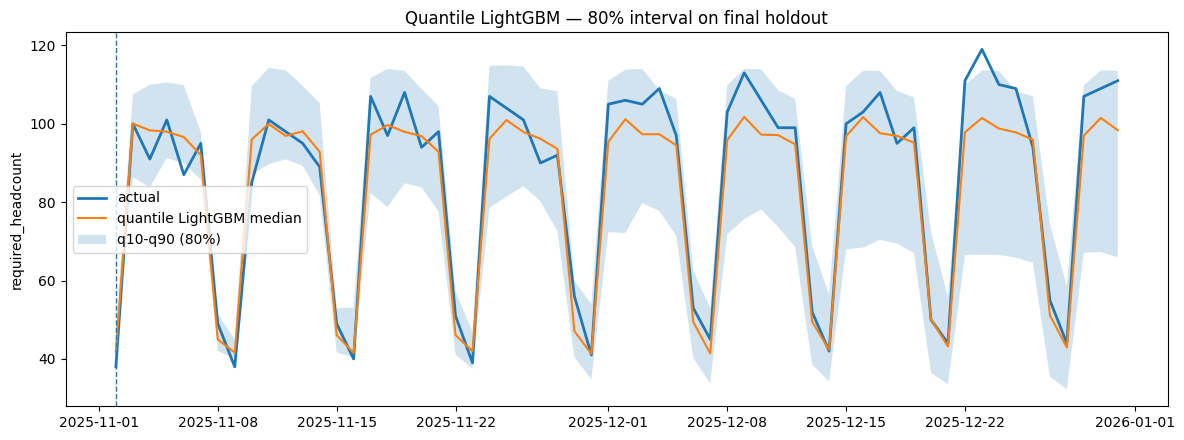

In [29]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test.index, test.values, label="actual", linewidth=2)
ax.plot(test.index, q50, label="quantile LightGBM median")
ax.fill_between(test.index, q10, q90, alpha=0.2, label="q10-q90 (80%)")
ax.axvline(test.index[0], linestyle="--", linewidth=1)
ax.set_title("Quantile LightGBM — 80% interval on final holdout")
ax.set_ylabel("required_headcount")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Model-family decision framework

Accuracy is necessary but not sufficient. The course asks for a deployment recommendation based on the properties of the forecasting problem. The table below compares all four named tools on the dimensions that matter for this workforce series.

| Family/tool | Strength on this series | Limitation / risk | Interval support | Compute / maintenance |
|---|---|---|---|---|
| **statsmodels (SARIMAX / ETS)** | Strong weekly structure, interpretable states/orders, stable on one series | Structural break is not known in advance; SARIMAX order maintenance is manual | Available, though the notebook separately demonstrates other interval APIs | Low |
| **Prophet** | Quick trend + weekly decomposition and native intervals | Can smooth through abrupt regime changes; still needs monitoring/recalibration | Native | Low-medium |
| **sktime** | Uniform forecasting API; easy to swap/benchmark estimators | Performance depends on wrapped estimator | Standard `predict_interval` / quantile interface | Medium |
| **LightGBM** | Flexible lag/rolling/calendar effects; useful if exogenous workforce drivers are later added | Recursive error propagation; feature engineering creates leakage risk if boundaries are mishandled | Quantile objective or conformal wrapper | Medium |

### Deployment recommendation
For a single workforce series with a known possibility of regime shifts, I would deploy a **simple seasonal model as the stable production baseline and keep LightGBM as a monitored challenger**, rather than selecting a model from one holdout alone. The deciding evidence is the walk-forward mean **and** fold-to-fold spread under both expanding and rolling histories, plus the interval calibration table. The structural-break stress test is also part of the decision: a sudden new regime is not forecastable before it appears, so the operational system must detect the error spike, shorten/reweight history if needed, and recalibrate uncertainty after the break.

This recommendation is intentionally conditional on the notebook's measured results. If the final Colab run shows a different ordering, the deployment choice should follow the same framework rather than preserving a pre-written winner.


## 10. Submission evidence checklist

- Decomposition is actually run with STL and interpreted.
- ACF/PACF are actually computed/plotted.
- ADF is actually run; differencing is tied to its result and the structural evidence.
- SARIMAX is actually fitted, and the order is selected by comparing AIC/BIC candidates.
- SES, Holt, and Holt-Winters are actually fitted.
- Ljung-Box residual diagnostics are actually run.
- LightGBM is actually fitted with lag, rolling, and calendar features.
- Leakage risk is addressed in both feature construction and recursive forecasting.
- `run_backtest` drives fresh fitting across real walk-forward folds.
- Both expanding and rolling windows are actually used.
- A seasonal-naive baseline is actually computed.
- MAE, RMSE, WAPE, and MASE come from the shared metrics module.
- Prophet is actually fitted and its native interval is evaluated.
- sktime `predict_interval` is actually called.
- Quantile forecasts are scored with pinball loss.
- Coverage and interval width are reported together.
- Conformal prediction is used as a distribution-free alternative.
- All four course tool families are discussed in the final decision framework.
- Repository documentation states the programme/cohort and links SDAIA Academy.


## 11. Final conclusion

This project turns the structural break into the central forecasting problem rather than treating it as an inconvenience. The result is a complete workflow: diagnose the series, motivate differencing, fit classical and ML models, validate them strictly forward in time, compare expanding and rolling history, stress-test the break itself, evaluate scale-aware accuracy, quantify uncertainty with four interval approaches, and select a deployment strategy using accuracy, stability, interpretability, interval support, and maintenance cost together.
